In [1]:
import meep as mp
import meep.adjoint as mpa
from meep.materials import Au, Ag 
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product, grad
import nlopt
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import time
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

In [2]:
dir_path = 'post-harm'
os.makedirs(dir_path, exist_ok=True)

In [3]:
mp.verbosity(1)
Air = mp.Medium(index=1)
Si = mp.Medium(index = 3.48)
resolution = 250 
dx = 0.8  #design_region_x_width = 1    
dy = 0.8  #design_region_y_width = 1   
pml_size = 0.8
air_size = 0.3
Sx = dx
Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)

# Mapping parameters
minimum_length = 0.01
eta_i = 0.5
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
design_region_resolution = int(resolution)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]

monitor_position = mp.Vector3(Sx/2 - pml_size - 0.1, 0, 0)
monitor_size1 = mp.Vector3(0, dy, 0)

# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
width = 0.2
fwidth = width * fcen
source_center = mp.Vector3(-Sx/2,0) 
src_size = dy + 2* air_size
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
# Design weight

Nx = int(design_region_resolution * dx) + 1
Ny = int(design_region_resolution * dy) + 1
design = np.load("data/final_design.npy")
design = design.reshape(Nx,Ny)
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), Air, Si,weights=design, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(dx, dy, 0),
    ),
)



# Setting geometry
geometry = [   
    mp.Block(center=design_region.center, size=design_region.size, material=design_variables),
]



# Main simulation
sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    k_point=mp.Vector3(),
    extra_materials=[Si],
) 

     block, center = (0,0,0)
          size (0.8,0.8,0)


          axes (1,0,0), (0,1,0), (0,0,1)


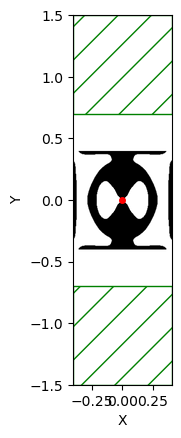

In [4]:
src = mp.GaussianSource(frequency=fcen, fwidth=1)
source = [mp.Source(src, component=mp.Ey, size=mp.Vector3(0,0), center=mp.Vector3(0,0))]
sim.change_sources(source)
sim.plot2D()
plt.show()
plt.close()


In [5]:
harminv_pt = mp.Vector3(0, 0)
h = mp.Harminv(mp.Ey, pt=harminv_pt, fcen=fcen, df=1)

# 執行模擬直到模態衰減
sim.run(mp.after_sources(h), until=2000)

# 擷取結果


-----------
Initializing structure...
time for choose_chunkdivision = 0.000211954 s
Working in 2D dimensions.
Computational cell is 0.8 x 3 x 0 with resolution 250
     block, center = (0,0,0)
          size (0.8,0.8,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.302813 s
-----------


FloatProgress(value=0.0, description='0% done ', max=2000.0)

Meep progress: 6.0280000000000005/2000.0 = 0.3% done in 4.0s, 1323.3s to go
on time step 3017 (time=6.034), 0.00132607 s/step
Meep progress: 11.24/2000.0 = 0.6% done in 8.0s, 1415.7s to go
on time step 5623 (time=11.246), 0.00153528 s/step
Meep progress: 15.658/2000.0 = 0.8% done in 12.0s, 1521.1s to go
on time step 7832 (time=15.664), 0.0018112 s/step
Meep progress: 20.452/2000.0 = 1.0% done in 16.0s, 1548.9s to go
on time step 10231 (time=20.462), 0.00166773 s/step
Meep progress: 26.142/2000.0 = 1.3% done in 20.0s, 1510.4s to go
on time step 13078 (time=26.156), 0.00140538 s/step
Meep progress: 32.102000000000004/2000.0 = 1.6% done in 24.0s, 1471.5s to go
on time step 16059 (time=32.118), 0.0013419 s/step
Meep progress: 38.124/2000.0 = 1.9% done in 28.0s, 1441.2s to go
on time step 19074 (time=38.148), 0.0013268 s/step
Meep progress: 46.632/2000.0 = 2.3% done in 32.0s, 1340.7s to go
on time step 23332 (time=46.664), 0.000939481 s/step
Meep progress: 55.846000000000004/2000.0 = 2.8% d

In [6]:
data = [
    {
        "frequency": mode.freq,
        "decay": mode.decay,
        "Q": mode.Q,
        "abs_amplitude": abs(mode.amp),
        "amplitude": mode.amp,
        "error": mode.err,
    }
    for mode in h.modes  # 過濾低 Q 或雜訊模態
]

df = pd.DataFrame(data)
df.to_csv(f"{dir_path}/harminv_qfactor.csv", index=False)
print(df)

   frequency         decay             Q  abs_amplitude             amplitude  \
0   0.642967 -4.613554e-09  6.968235e+07      81.294548 -17.498770+79.388894j   
1   0.950445  5.285076e-07 -8.991781e+05       6.804726  -0.137072- 6.803345j   
2   1.104477  7.786373e-06 -7.092371e+04       0.003217   0.002772- 0.001633j   

                                            error  
0  7.780993e-11+0.000000e+                    00j  
1  5.626491e-10+0.000000e+                    00j  
2  7.269863e-07+0.000000e+                    00j  
